##### Camada GOLD - Analise dos dados do portal e transparencia


##### Conexao com o banco de dados

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

import banco  # banco.py esta na mesma pasta deste notebook

conexao = banco.conectar()

def consultar(sql):
    """Roda um SELECT e devolve o resultado como DataFrame do pandas."""
    return pd.read_sql(sql, conexao)

def reais(valor):
    """Formata um numero como moeda brasileira: 1234.5 -> 'R$ 1.234,50'."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')

print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


#####  Pergunta 1 - Os 5 órgãos com maior custo total? 


In [3]:
df_gold = consultar("""SELECT * FROM golden_maior_custo limit 5;""")
df_gold['valor_total'] = df_gold['valor_total'].apply(reais)
df_gold.style.hide(axis='index').set_properties(**{'text-align': 'left'})


C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


nome_orgao_superior,valor_total
MINISTÉRIO DA JUSTIÇA E SEGURANÇA PÚBLICA,"R$ 490.813.474,85"
MINISTÉRIO DA DEFESA,"R$ 157.059.698,59"
MINISTÉRIO DA EDUCAÇÃO,"R$ 112.519.456,96"
MINISTÉRIO DO MEIO AMBIENTE E MUDANÇA DO CLIMA,"R$ 50.548.377,44"
MINISTÉRIO DA PREVIDÊNCIA SOCIAL,"R$ 40.921.476,10"


C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


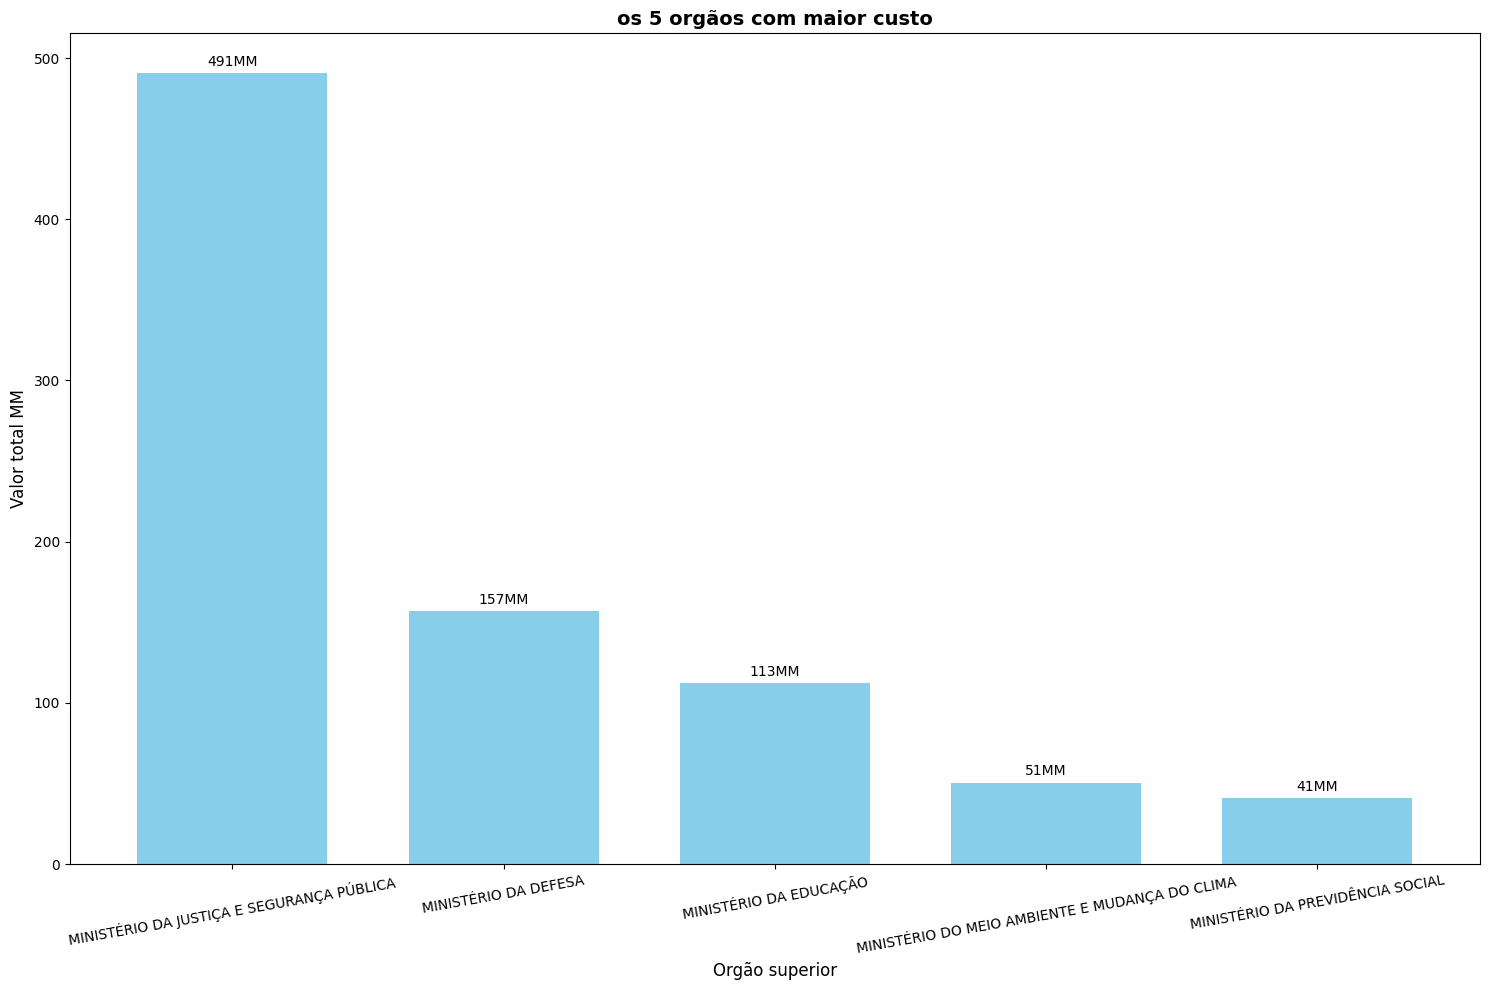

In [37]:
# Grafico
df_gra1 = consultar("""SELECT * FROM golden_maior_custo limit 5;""")
df = pd.DataFrame(df_gra1)
df['valor_total'] = (df['valor_total'].astype(int) / 1000000)

fig, ax = plt.subplots(figsize=(15, 10))

df.plot(kind='bar',x='nome_orgao_superior',y='valor_total',ax=ax, color='skyblue', width=0.7)


ax.set_title('os 5 orgãos com maior custo', fontsize=14, fontweight='bold')
ax.set_xlabel('Orgão superior', fontsize=12)
ax.set_ylabel('Valor total MM', fontsize=12)

ax.bar_label(ax.containers[0], color='black', fmt='{:,.0f}MM', padding=3)

plt.xticks(rotation=10)
plt.legend().remove()
plt.tight_layout()
plt.show()



##### Pergunta 2 - Os 3 destinos com maior custo médio por viagem?


In [41]:
df_gold_2 = consultar("""SELECT * FROM golden_custo_destino limit 3;""")
df_gold_2['custo_medio'] = df_gold_2['custo_medio'].apply(reais)
df_gold_2

C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destinos,custo_medio
0,"ABU DABI/EMIRADOS ÁRABES, RIAD/ARÁBIA SAUDITA,...","R$ 245.852,80"
1,"BRASÍLIA/DF, RIO BRANCO/AC, CRUZEIRO DO SUL/AC...","R$ 216.729,36"
2,"BRASÍLIA/DF, RIO DE JANEIRO/RJ, ANGRA DOS REIS...","R$ 207.220,14"


##### Pergunta 3 - A viagem de maior duração e seu custo total? 

In [60]:
df_gold_3 = consultar("""SELECT * FROM golden_duracao_custo limit 4;""")
df_gold_3['valor_total'] = df_gold_3['valor_total'].apply(reais)
df_gold_3.style.hide(axis='index').set_properties(**{'text-align': 'left'})

C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


id_viagem,nome_orgao_superior,destinos,duracao_dias,valor_total
0000000000020699856,MINISTÉRIO DA PREVIDÊNCIA SOCIAL,MOGI MIRIM/SP,383,"R$ 0,00"
0000000000020793594,MINISTÉRIO DA JUSTIÇA E SEGURANÇA PÚBLICA,INFORMAÇÕES PROTEGIDAS POR SIGILO,378,"R$ 120.650,00"
0000000000020793492,MINISTÉRIO DA JUSTIÇA E SEGURANÇA PÚBLICA,INFORMAÇÕES PROTEGIDAS POR SIGILO,369,"R$ 113.382,50"
0000000000020774569,MINISTÉRIO DA EDUCAÇÃO,BARILOCHE/ARGENTINA,369,"R$ 0,00"


##### Pergunta 4 - Qual o tipo de pagamento com maior valor médio?

In [61]:
df_gold_4 = consultar("""SELECT * FROM golden_pagamento_medio limit 4;""")
df_gold_4['valor_medio'] = df_gold_4['valor_medio'].apply(reais)
df_gold_4.style.hide(axis='index').set_properties(**{'text-align': 'left'})

C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


tipo_de_pagamento,valor_medio
DIÁRIAS,"R$ 2.078,28"
PASSAGEM,"R$ 1.878,34"
SERVIÇO CORRELATO: SEGURO,"R$ 447,51"
RESTITUIÇÃO,"R$ 245,70"


C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


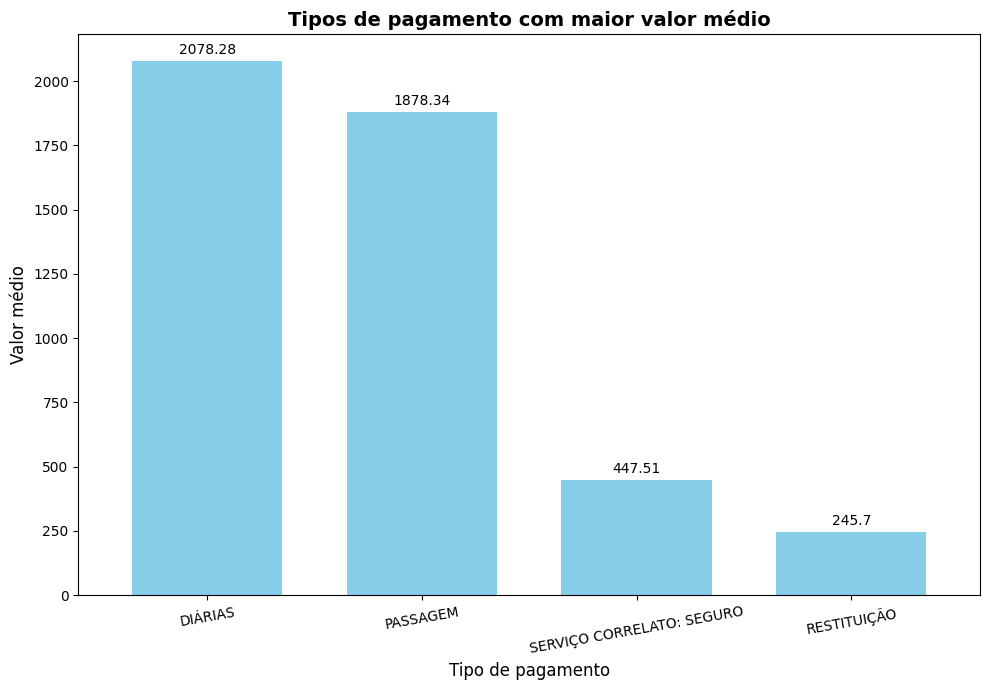

In [66]:
# Grafico
df_gra4 = consultar("""SELECT * FROM golden_pagamento_medio limit 5;""")
df = pd.DataFrame(df_gra4)

fig, ax = plt.subplots(figsize=(10, 7))

df.plot(kind='bar',x='tipo_de_pagamento',y='valor_medio',ax=ax, color='skyblue', width=0.7)


ax.set_title('Tipos de pagamento com maior valor médio', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de pagamento', fontsize=12)
ax.set_ylabel('Valor médio', fontsize=12)

ax.bar_label(ax.containers[0], color='black', padding=3)

plt.xticks(rotation=10)
plt.legend().remove()
plt.tight_layout()
plt.show()


##### Pergunta 5 - Qual o meio de transporte mais usado nos trechos?

In [57]:
df_gold_5 = consultar("""SELECT * FROM golden_transporte_trechos limit 4;""")
df_gold_5.style.hide(axis='index').set_properties(**{'text-align': 'left'})

C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


meio_transporte,qtd_trechos
VEÍCULO OFICIAL,386424
AÉREO,232666
RODOVIÁRIO,64970
VEÍCULO PRÓPRIO,42846


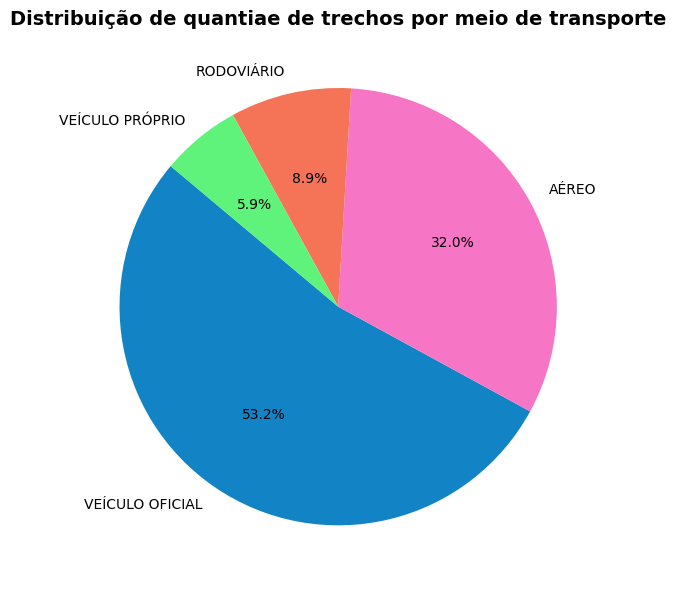

In [58]:
df_graf_5 = df_gold_5.set_index('meio_transporte')

cores = ["#1284C6","#F775C5","#F57457","#60F37B","#6678C6","#6A1370","#DCF55E"]

df_graf_5['qtd_trechos'].plot.pie(
    y="PR_ID", 
    autopct='%.1f%%', 
    figsize=(8, 6),
    colors=cores,        
    startangle=140,
    legend=False 
)

plt.title('Distribuição de quantiae de trechos por meio de transporte', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()             
plt.show()

##### Pergunta 6 - Qual UF de destino aparece em mais trechos?

In [48]:
df_gold_6 = consultar("""SELECT * FROM golden_UF_trechos limit 5;""")
df_gold_6.style.hide(axis='index').set_properties(**{'text-align': 'left'})

C:\Users\rehfe\AppData\Local\Temp\ipykernel_6912\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


destino_UF,qtd_trechos
SÃO PAULO,82722
DISTRITO FEDERAL,79962
MINAS GERAIS,50965
RIO DE JANEIRO,44197
PARANÁ,42603


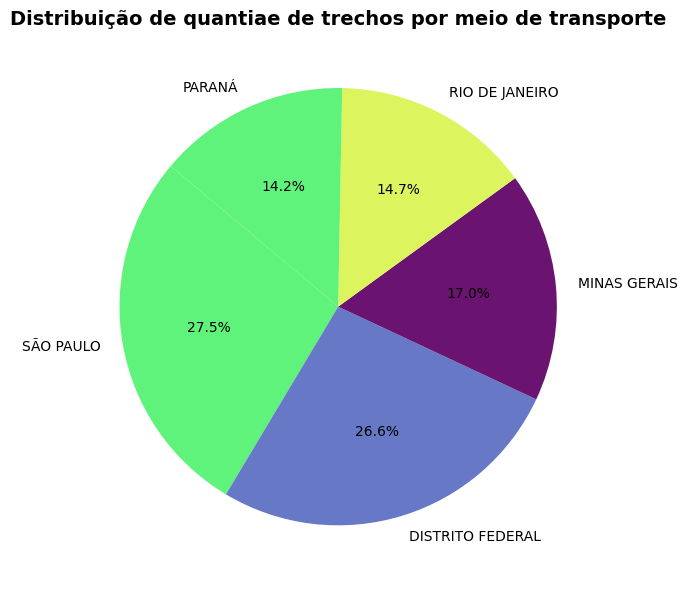

In [68]:
df_graf_6 = df_gold_6.set_index('destino_UF')

cores = ["#60F37B","#6678C6","#6A1370","#DCF55E"]

df_graf_6['qtd_trechos'].plot.pie(
    y="PR_ID", 
    autopct='%.1f%%', 
    figsize=(8, 6),
    colors=cores,        
    startangle=140,
    legend=False 
)

plt.title('Distribuição de quantiae de trechos por meio de transporte', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()             
plt.show()

##### Pergunta 7 - Qual órgão pagou mais no total? 

In [8]:
df_gold_7 = consultar("""SELECT * FROM golden_orgao_custo limit 5;""")
df_gold_7['total_pago'] = df_gold_7['total_pago'].apply(reais)
df_gold_7.style.hide(axis='index').set_properties(**{'text-align': 'left'})

C:\Users\rehfe\AppData\Local\Temp\ipykernel_14448\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


nome_orgao_superior,total_pago
MINISTÉRIO DA JUSTIÇA E SEGURANÇA PÚBLICA,"R$ 490.813.474,85"
MINISTÉRIO DA DEFESA,"R$ 157.059.698,59"
MINISTÉRIO DA EDUCAÇÃO,"R$ 112.519.456,96"
MINISTÉRIO DO MEIO AMBIENTE E MUDANÇA DO CLIMA,"R$ 50.548.377,44"
MINISTÉRIO DA PREVIDÊNCIA SOCIAL,"R$ 40.921.476,10"


C:\Users\rehfe\AppData\Local\Temp\ipykernel_14448\4248943652.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


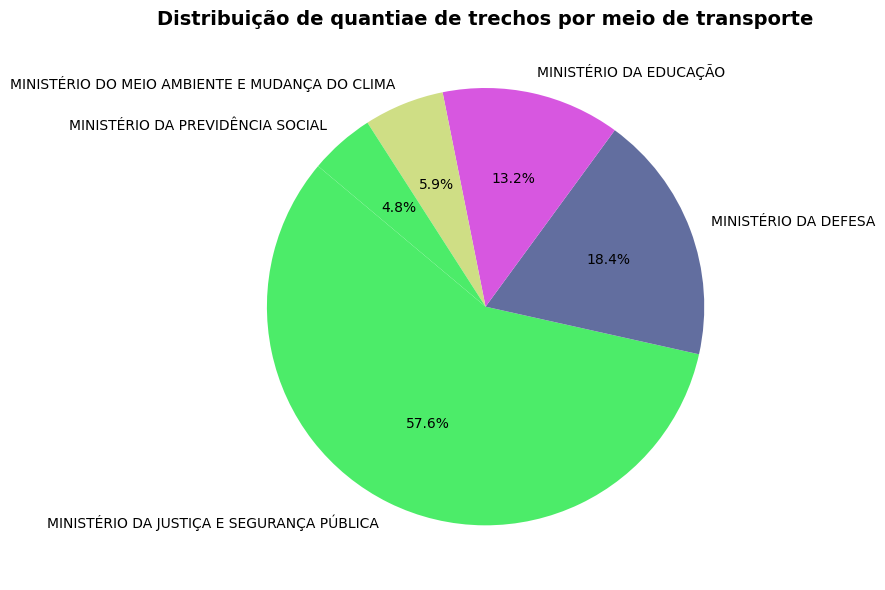

In [10]:
df_gold_ = consultar("""SELECT * FROM golden_orgao_custo limit 5;""")
df_graf_7 = df_gold_.set_index('nome_orgao_superior')

cores = ["#4CEC69","#626E9F","#D757E0","#CFDE85"]

df_graf_7['total_pago'].plot.pie(
    y="PR_ID", 
    autopct='%.1f%%', 
    figsize=(8, 6),
    colors=cores,        
    startangle=140,
    legend=False 
)

plt.title('Distribuição de quantiae de trechos por meio de transporte', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()             
plt.show()

In [21]:
# Encerra a conexao com o banco
conexao.close()
print('Conexao encerrada.')

Conexao encerrada.
